# Mosaic vs. stacked bar

These are **two plot types**, not one plot type with a switch:

| | Column widths | Reads best when |
|---|---|---|
| `type="mosaic"` | proportional to how often each x value occurred | few categories |
| `type="stackedbar"` | all the same | many categories, or some are rare |

In both, a column is one x value and the segments stacked inside it are y's
**conditional** distribution given that x value. Comparing segment heights
across columns is how you see whether y depends on x. Those heights are
identical between the two types -- only the widths differ.

> These replaced the old `type="mosaic", equal_width=True`. The
> `equal_width=` and `marginal_column=` keywords are gone; passing either one
> now raises a message pointing at the replacement.

In [1]:
from symbulate import *
import numpy as np

## A skewed x variable

`x` is `Bernoulli(p=0.9)`, so about 90% of the draws are 1. In a mosaic that
shows up directly as column width -- the `1` column is roughly nine times
wider than the `0` column.

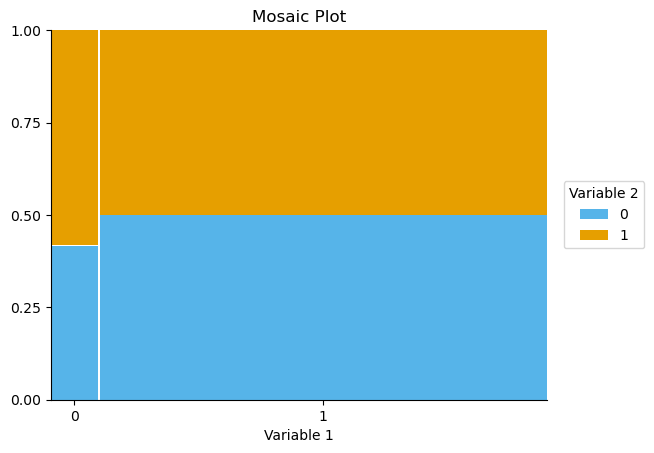

In [2]:
np.random.seed(7)
X, Y = RV(Bernoulli(p=0.9) * Bernoulli(p=0.5))
skewed = (X & Y).sim(500)

skewed.plot(type="mosaic", suggest=False)

## The same data as a stacked bar

Both columns are now equally wide. The segment heights are unchanged -- only
the layout is different -- and the title says which one you are looking at.

Notice what is lost and gained: you can no longer see that `1` is far more
common than `0`, but the rare `0` column is now big enough to read.

This stacked bar plot has only 2 x-categories and 2 y-categories. With this few, try type='mosaic' -- it draws each column's width in proportion to how often that category occurred, so the plot also shows which categories are common.


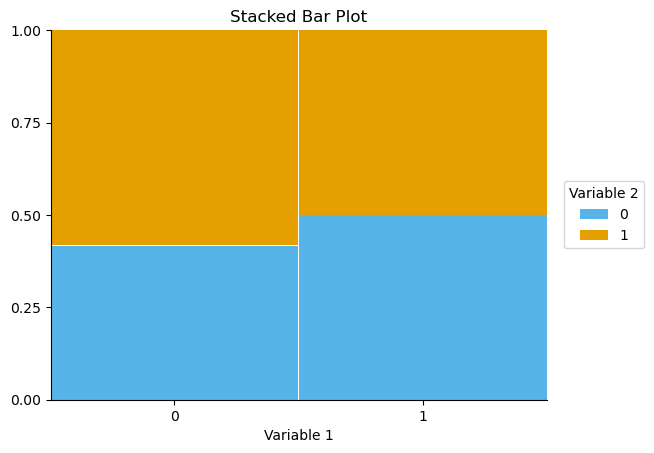

In [3]:
skewed.plot(type="stackedbar", suggest=False)

## Symbulate suggests the other one when it would read better

Neither type is ever refused, but a mosaic with many categories gets thin
columns, and a stacked bar with only a few is throwing away the width
information a mosaic would show. Either way you get a note, not an error.

Here `x` is `Binomial(6, 0.3)`, so it has 7 categories (0 through 6), past the 4-category cutoff:

This mosaic plot has 7 x-categories and 2 y-categories. With this many, the rarer columns get too thin to compare -- try type='stackedbar', which draws every column the same width.


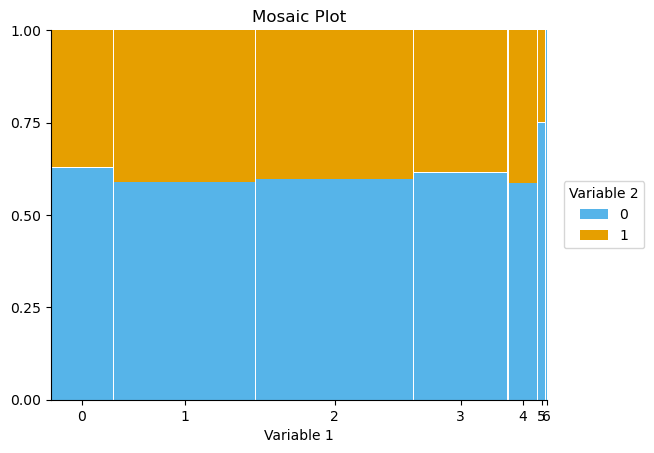

In [4]:
np.random.seed(3)
Xm, Ym = RV(Binomial(n=6, p=0.3) * Bernoulli(p=0.4))
many = (Xm & Ym).sim(1500)

many.plot(type="mosaic", suggest=False)   # prints a nudge toward stackedbar

The suggested version -- every category readable, however rare:

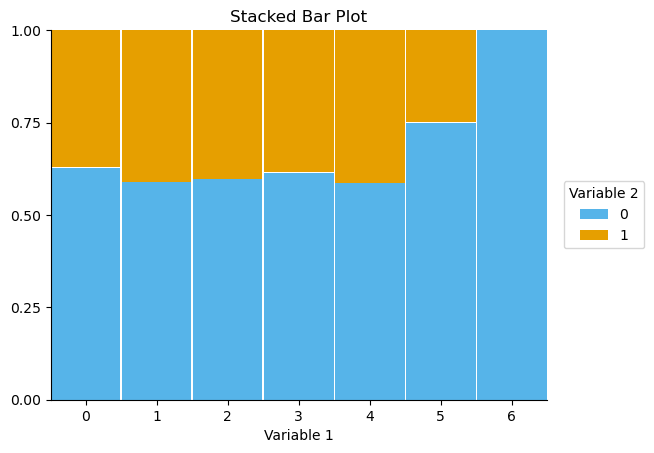

In [5]:
many.plot(type="stackedbar", suggest=False)

## Every column fills the axis

A column that is missing one of the y categories still runs from 0 to 1. (It
used to stop slightly short, leaving a thin blank strip where the absent
category's gap had been reserved.)

Below, `y` is always 0 when `x` is 0, so that column has only one segment:

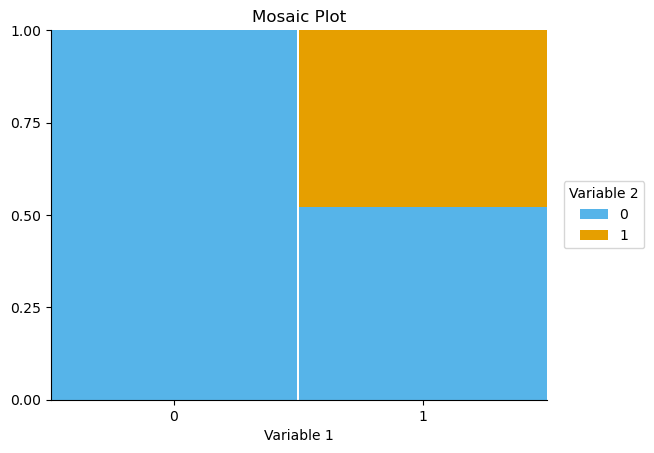

In [6]:
np.random.seed(11)
Xz = RV(Bernoulli(p=0.5))
Yz = Xz.apply(lambda v: int(v) * np.random.binomial(1, 0.5))
(Xz & Yz).sim(600).plot(type="mosaic", suggest=False)

## Two of these can't share one plot

Each type divides up the whole plot area for its own data, so a second one
would completely cover the first. That is refused rather than drawn:

ValueError: You can't draw a second mosaic or stacked bar plot on the same axes. Each one divides the whole plot area up for its own data, so the second would completely cover the first. Draw them as two separate plots instead -- in Jupyter, put each .plot() call in its own cell.


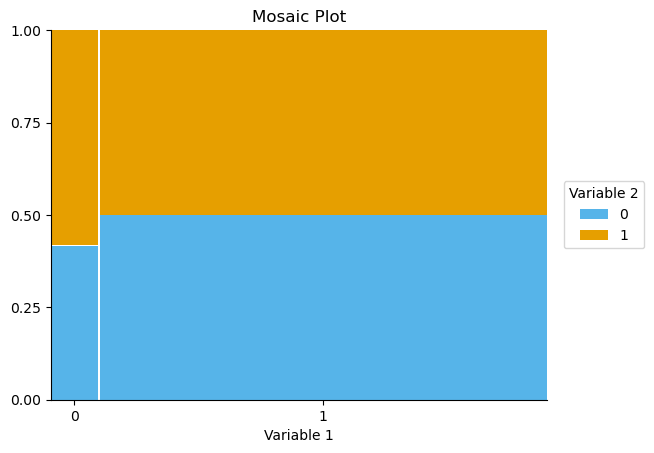

In [7]:
skewed.plot(type="mosaic", suggest=False)
try:
    skewed.plot(type="stackedbar", suggest=False)
except ValueError as e:
    print("ValueError:", e)

## The removed keywords

Both old keywords raise a message naming what to use instead, rather than
failing somewhere deep inside matplotlib:

In [8]:
for bad in [{"equal_width": True}, {"marginal_column": True}]:
    try:
        skewed.plot(type="mosaic", suggest=False, **bad)
    except ValueError as e:
        print(f"{list(bad)[0]}= ->", e, end="\n\n")

equal_width= -> equal_width= is no longer a plotting argument: the two column widths are now separate plot types. Use type='stackedbar' for equal-width columns, or type='mosaic' for widths proportional to how often each category occurred.

marginal_column= -> marginal_column= is no longer a plotting argument. A mosaic or stacked bar plot now names its categories with a legend instead of an extra column. To see one variable's overall distribution on its own, plot that variable by itself.



<Figure size 640x480 with 0 Axes>